In [ ]:
## Vanilla Gan Implemention

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Reshape, Flatten
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

In [3]:
# random seed
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
### Load and Normalize in mnist dataset
(x_train, _), (_, _) = mnist.load_data()
X_train = x_train / 127.5 - 1.0 ## Normalize to [-1, 1]
X_train = x_train.reshape(-1, 28 * 28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [7]:
### Set dimension
img_shape = (28, 28)
laltent_dim = 100

In [8]:
#----------------
# Build Generator
#----------------

def build_generator():
  model = Sequential()
  model.add(Dense(128, input_dim=laltent_dim))
  model.add(LeakyReLU(0.2))
  model.add(Dense(784, activation='tanh'))
  model.add(Reshape(img_shape))
  return model


In [9]:
#----------------
# Build Discriminator
#----------------

def build_Discriminator():
  model = Sequential()
  model.add(Flatten(input_shape=img_shape))
  model.add(Dense(128))
  model.add(LeakyReLU(0.2))
  model.add(Dense(1, activation='sigmoid'))
  return model

In [11]:
#----------------
# Build and Compile Discriminator
#----------------

discriminator = build_Discriminator()
discriminator.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))

## Build Generator
generator = build_generator()

### Create Gan Model (Gen + Dis)
z = tf.keras.Input(shape=(laltent_dim,))
img = generator(z)
discriminator.trainable = False
valid = discriminator(img)

gan = tf.keras.Model(z, valid)
gan.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
def train(epochs, batch_size=128, sample_interval=1000):
    half_batch = batch_size // 2

    for epoch in range(epochs):

        # Train Discriminator
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        real_imgs = X_train[idx].reshape(-1, 28, 28)

        noise = np.random.normal(0, 1, (half_batch, laltent_dim))
        fake_imgs = generator.predict(noise)

        d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((half_batch, 1)))
        d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((half_batch, 1)))
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # Train Generator
        noise = np.random.normal(0, 1, (batch_size, laltent_dim))
        g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

        # Display progress
        if epoch % sample_interval == 0:
            print(f"{epoch} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.2f}%] [G loss: {g_loss:.4f}]")
            sample_images(epoch)

# ----------------------------
# Image Sampling
# ----------------------------
def sample_images(epoch, n=5):
    noise = np.random.normal(0, 1, (n * n, laltent_dim))
    gen_imgs = generator.predict(noise)

    gen_imgs = 0.5 * gen_imgs + 0.5  # Rescale to [0, 1]

    fig, axs = plt.subplots(n, n)
    cnt = 0
    for i in range(n):
        for j in range(n):
            axs[i, j].imshow(gen_imgs[cnt], cmap='gray')
            axs[i, j].axis('off')
            cnt += 1
    plt.tight_layout()
    plt.savefig(f"gan_mnist_epoch_{epoch}.png")
    plt.show()
    plt.close()

In [15]:
train(epochs=5001, batch_size=64, sample_interval=500)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


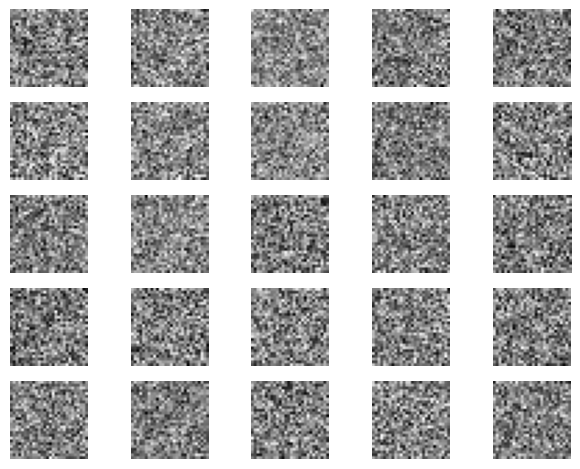

In [15]:
sample_images(epoch=2000, n=5)